In [1]:
import pandas as pd # Nos permite manejar y transformar datos en estructuras tipo DataFrame
import numpy as np # Nos ayuda con cálculos numéricos y operaciones estadísticas sobre arreglos de datos
import matplotlib.pyplot as plt # Nos ayuda a crear gráficos y visualizaciones básicas
import seaborn as sns # Extiende Matplotlib y facilita la creación de gráficos estadísticos más atractivos y complejos
%matplotlib inline # Asegura que los gráficos se muestren directamente en la celda de salida

In [2]:
# Usamos read_json de Pandas para leer el archivo .log
# 'lines=true' indica que cada línea del archivo corresponde a un objeto JSON independiente
# Permite que Pandas convierta automáticamente cada línea en una fila del DataFrame
# El resultado se guarda en la variable 'df', siendo nuestro principal DataFrame
df = pd.read_json(r"C:\Users\ferdo\Downloads\20250929-enroll.log", lines=True)

# Mostramos las primeras 5 filas del DataFrame con el método .head()
print(df.head())

                    tiempo  estado metodo  \
0  2025-09-29 15:17:03.033     201   POST   
1  2025-09-29 15:17:03.112     201   POST   
2  2025-09-29 15:17:03.177     201   POST   
3  2025-09-29 15:17:03.235     201   POST   
4  2025-09-29 15:17:03.249     201   POST   

                                              pedido           server  \
0  /L9h/v3/envases/grupo1/nombres/0000030b0dc3b26...  L9h/25.9.pre.17   
1  /L9h/v3/envases/grupo1/nombres/000001d0b47bfe4...  L9h/25.9.pre.17   
2  /L9h/v3/envases/grupo1/nombres/0000015883985e9...  L9h/25.9.pre.17   
3  /L9h/v3/envases/grupo1/nombres/000002315c4ee98...  L9h/25.9.pre.17   
4  /L9h/v3/envases/grupo1/nombres/000001a3ab59eab...  L9h/25.9.pre.17   

             baliza     acceso             fuentes  decode  detect  refine  \
0  b82b54b74d610220  127.0.0.1  [5ff320fa3317f708]   4.608  28.505   0.644   
1  72ab230a1cc36242  127.0.0.1  [9d4a59c4b31af286]   0.937  50.442   1.092   
2  e0a7d3be532e2ba4  127.0.0.1  [544476bc72b75223]   1.1

In [12]:
# Exportamos el DataFrame 'df' a un archivo CSV
# 'index=False' evita que se guarde la columna de índices de Pandas, asi el archivo quede más limpio
# 'encoding="utf-8"' asegura que los caracteres especiales se guarden correctamente y sea compatible
df.to_csv("20250929-enroll-ordenado.csv", index=False, encoding="utf-8")

In [13]:
# Exportamos nuestro DataFrame a un archivo excel
# 'index=False' evita que se guarde la columna de índices de Pandas
# Asi el archivo solo contendrá las columnas originales de los datos
df.to_excel("enroll_excel.xlsx", index=False)

In [14]:
# Creamos una lista con los nombres de las columnas del DataFrame con los datos númericos
# Guardamos la lista en la variable 'columnas' y estas son las que se analizarán estadísticamente
columnas = ['decode', 'detect', 'refine', 'assess', 'vector', 'search', 'verify', 'commit', 'entire']

In [15]:
# Convertimos las columnas listadas a tipo numérico con la función 'pd.to_numeric'
# Con 'errors="coerce"' forzamos a que cualquier valor no convertible se convierta en NaN
df[columnas] = df[columnas].apply(pd.to_numeric, errors='coerce')

In [16]:
media = df[columnas].mean()
mediana = df[columnas].median()
moda = df[columnas].mode().iloc[0]
desviacion = df[columnas].std()
kurtosis = df[columnas].kurtosis()
sesgo = df[columnas].skew()

In [17]:
estadisticas = pd.DataFrame({
    'Media': media, # Calculamos la media (promedio)
    'Mediana': mediana, # Calculamos la mediana (valor central de los datos ordenados)
    'Moda': moda, # Calculamos la moda (valor más frecuente)
    'Desviación estándar': desviacion, # Calculamos la desviación estándar (dispersión de los datos respecto a la media)
    'Kurtosis': kurtosis, # Calculamos la curtosis (grado de concentración de los datos en torno a la media)
    'Sesgo': sesgo # Calculamos el sesgo (mide si la distribución de los datos está inclinada hacia la izquierda o derecha (negativo,positivo))
})

In [18]:
# Mostramos en pantalla la tabla de estadísticas
print (estadisticas)

            Media  Mediana    Moda  Desviación estándar     Kurtosis  \
decode   1.446256    1.277   1.090             2.250444   580.594455   
detect  14.637524   12.756   3.466             8.809122     3.256254   
refine   1.259194    0.947   0.000             1.058517  1108.919302   
assess   0.000000    0.000   0.000             0.000000     0.000000   
vector  21.345362   21.281   0.000             9.208229     2.598465   
search   0.000000    0.000   0.000             0.000000     0.000000   
verify   0.000000    0.000   0.000             0.000000     0.000000   
commit  50.259868    4.721   4.181            66.193784    -0.819282   
entire  89.010781   49.214  38.847            72.426508    -0.869164   

            Sesgo  
decode  23.030035  
detect   1.271743  
refine   8.275066  
assess   0.000000  
vector   0.649639  
search   0.000000  
verify   0.000000  
commit   0.918728  
entire   0.840280  


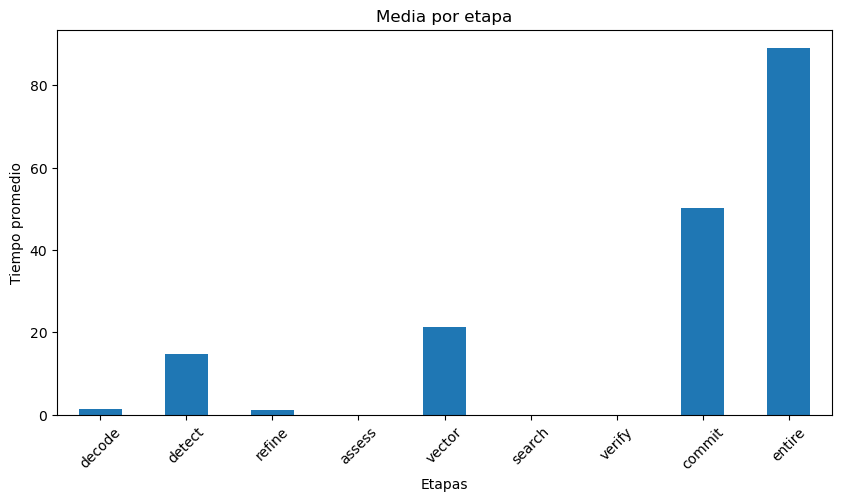

In [20]:
# Calculamos la media de cada columna numérica en la lista 'columnas'
# El resultado es una Serie de Pandas donde el índice son los nombres de las columnas 
# y los valores son las medias correspondientes
medias = df[columnas].mean()

plt.figure(figsize=(10,5)) # Definimos el tamaño de la figura del gráfico
medias.plot(kind='bar') # Usamos el método .plot() de Pandas para graficar las medias en un gráfico de barras
                        # 'kind="bar"' indica que queremos un gráfico de barras verticales
plt.title('Media por etapa') # Asignamos un título al gráfico
plt.ylabel('Tiempo promedio') ## Etiquetamos el eje Y indicando que representa el promedio de los valores
plt.xlabel('Etapas') # Etiquetamos el eje X indicando que cada barra corresponde a una etapa (columna)
plt.xticks(rotation=45) # Rotamos las etiquetas del eje X 45 grados para que se lean mejor
plt.show() # Mostramos el gráfico en pantalla

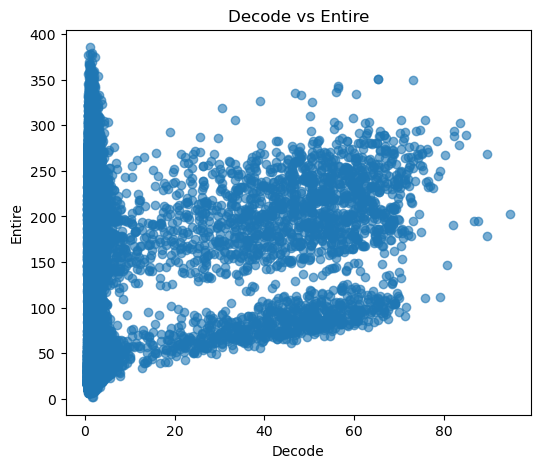

In [21]:
# Gráfica de dispersión

plt.figure(figsize=(6,5)) # Definimos el tamaño de la figura
plt.scatter(df['decode'], df['entire'], alpha=0.6) # Creamos un gráfico de dispersión con los valores de 'decode' y de 'entire' 
plt.title('Decode vs Entire') # Asignamos un título al gráfico
plt.ylabel('Entire') # Etiquetamos el eje Y con el nombre de la columna correspondiente
plt.xlabel('Decode') # Etiquetamos el eje X con el nombre de la columna correspondiente
plt.show() # Mostramos el gráfico en pantalla

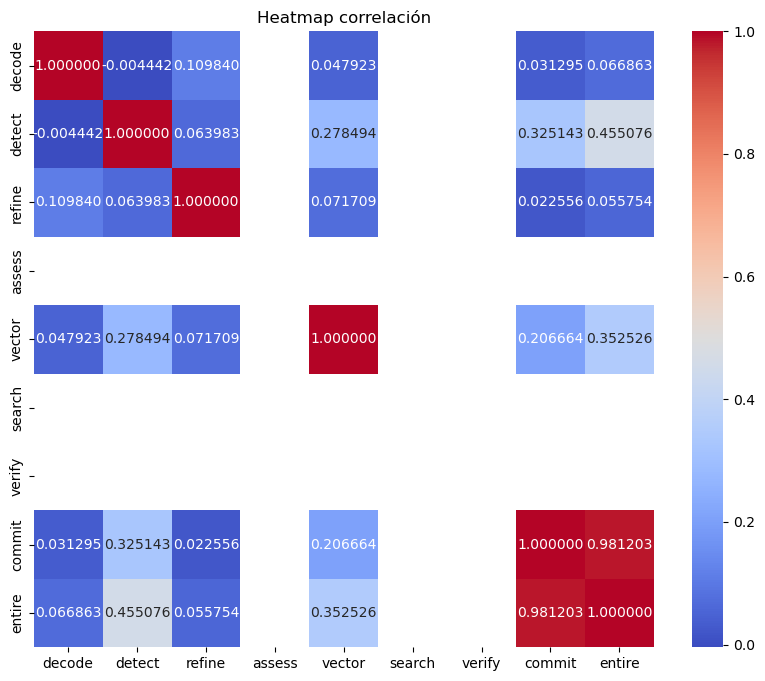

In [22]:
# Calculamos la matriz de correlación entre las columnas numéricas
# .corr() devuelve un DataFrame donde cada celda representa el coeficiente de correlación
correlacion = df[columnas].corr()
 
plt.figure(figsize=(10,8)) # Definimos el tamaño de la figura
sns.heatmap(
    correlacion, 
    annot=True, #Muestra los valores numéricos dentro de cada celda
    cmap='coolwarm', # Define la paleta de colores: azul para negativas, rojo para positivas
    fmt='2f' # Formato de los números: dos decimales
)

plt.title('Heatmap correlación') # Asignamos un título al gráfico
plt.show() # Mostramos el heatmap en pantalla

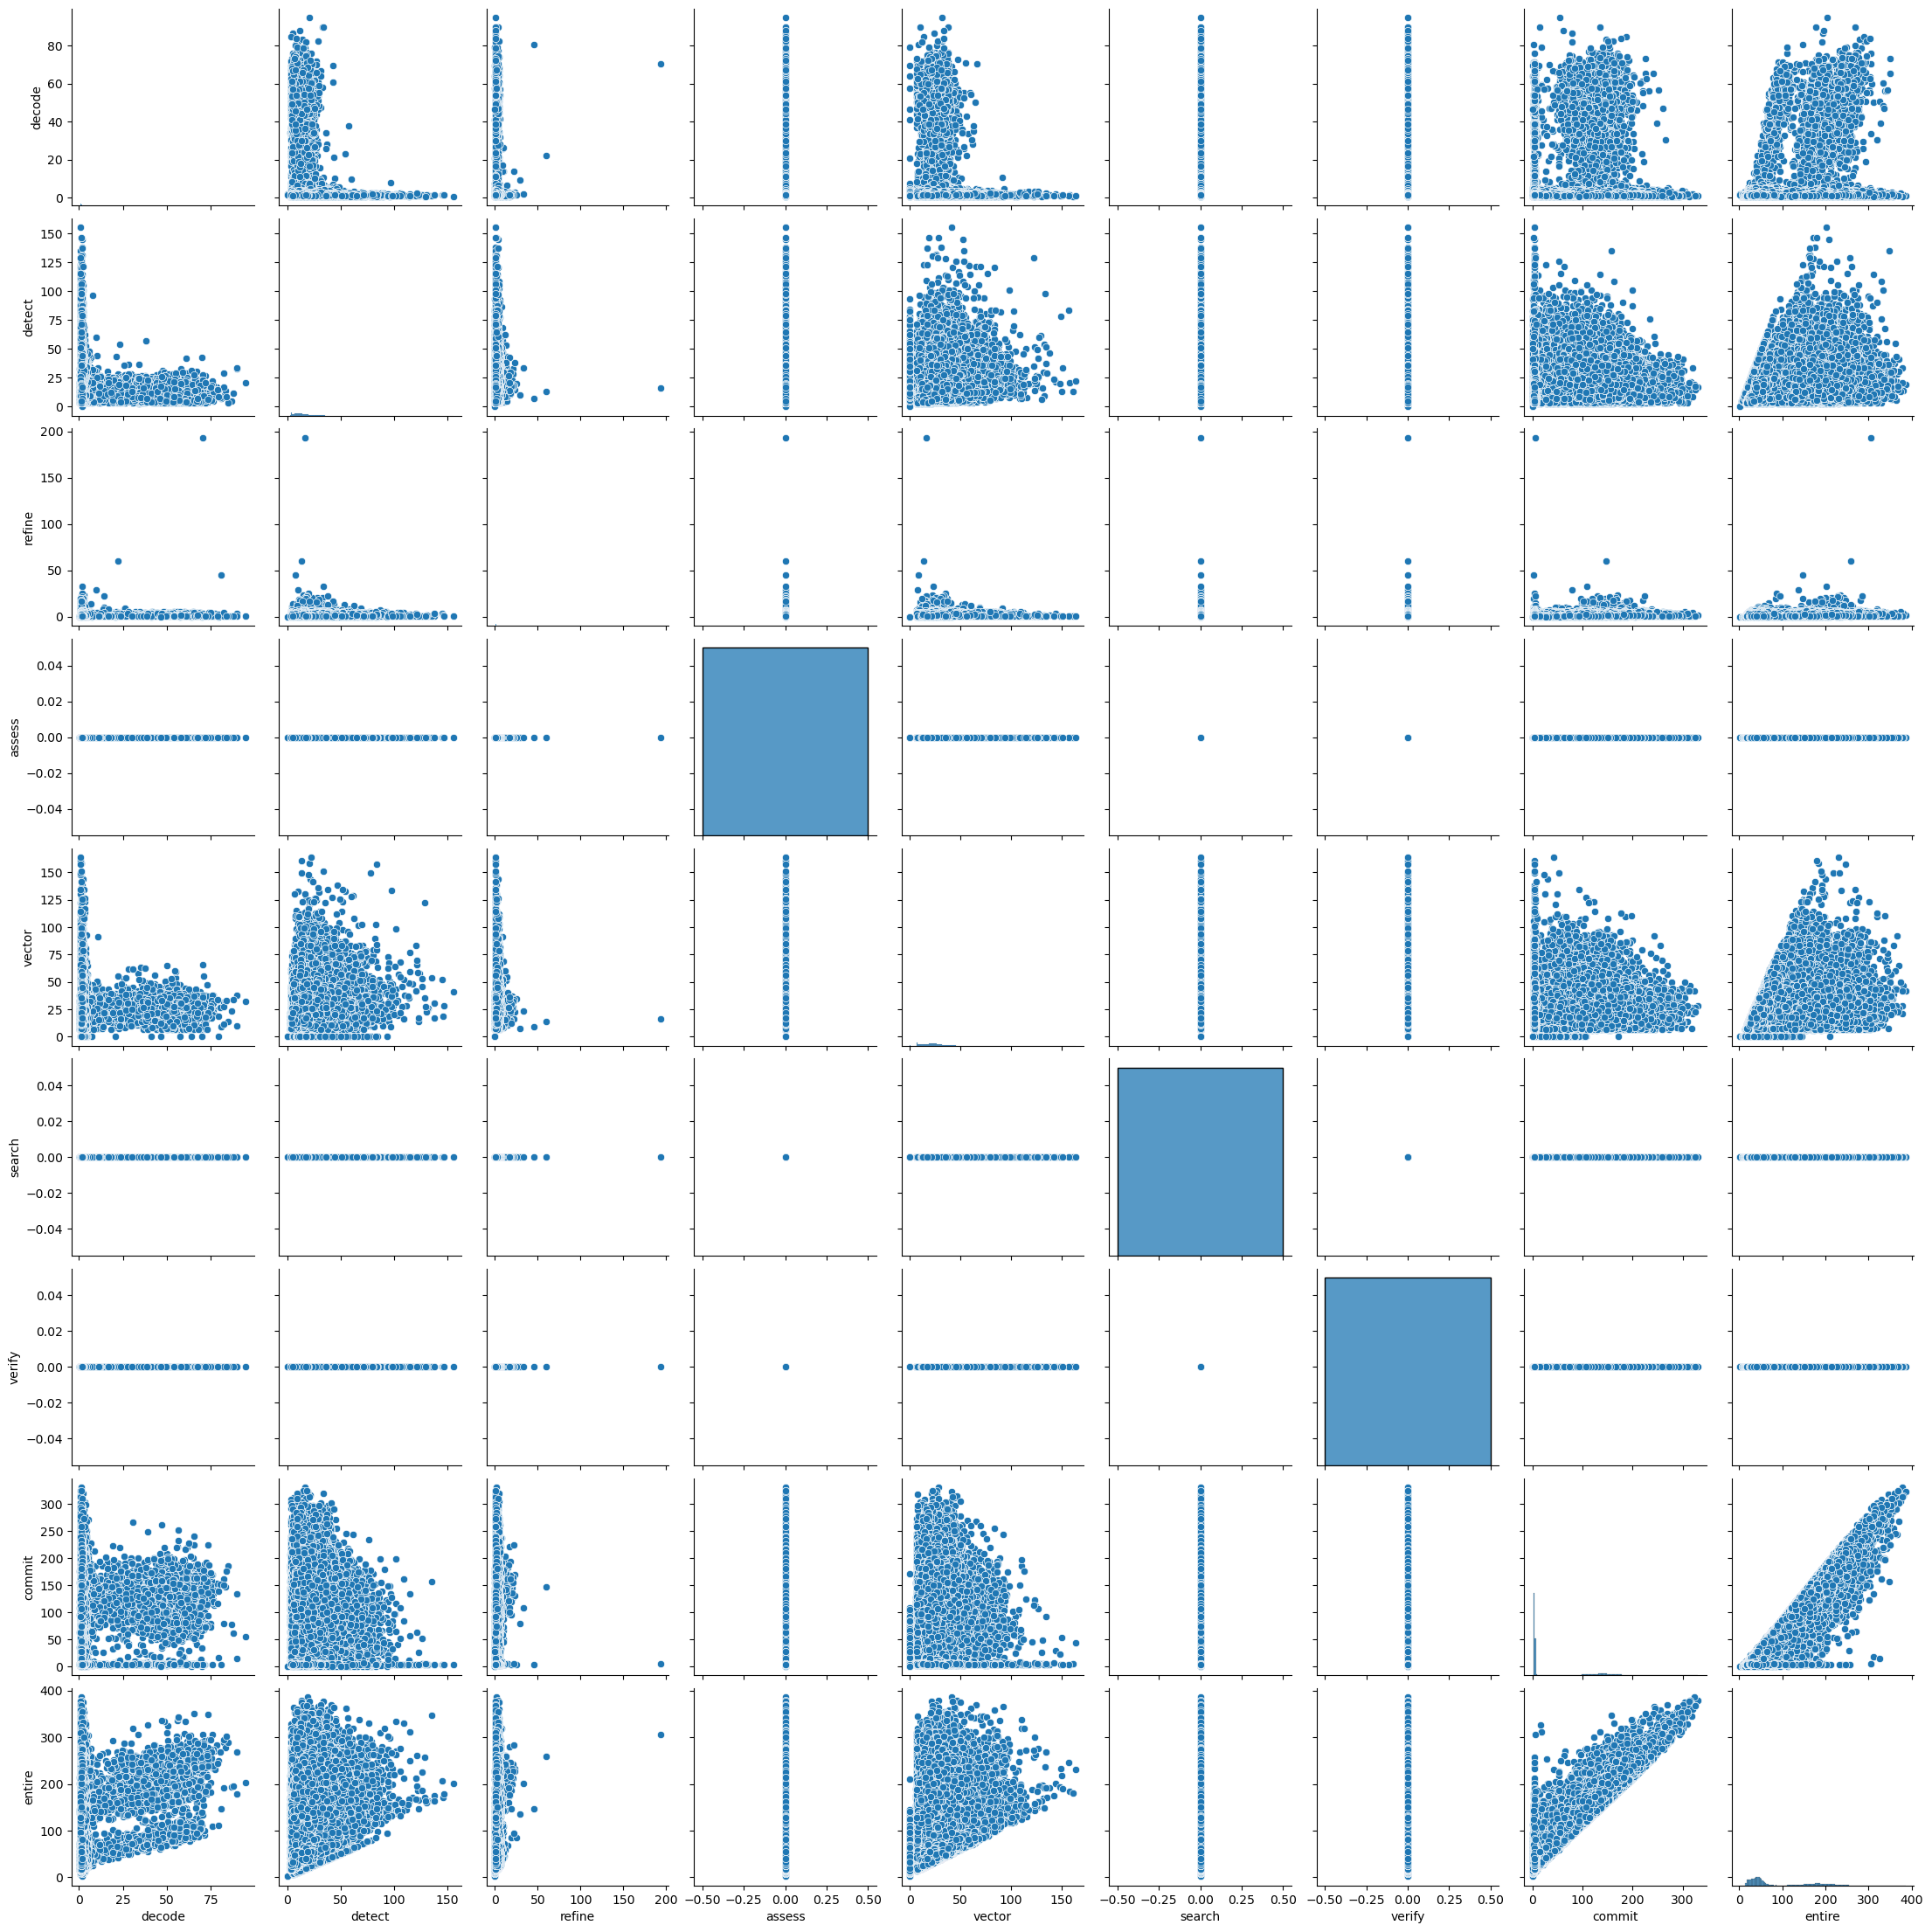

In [23]:
# Generamos un gráfico de pares (pairplot) con Seaborn
# Este gráfico muestra todas las combinaciones posibles de las columnas numéricas
sns.pairplot(df[columnas])
plt.show() # Mostramos el gráfico en pantalla